<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 12.2**</span> In an experiment, you measure the voltage across a resistor as you vary the current. According to Ohm's Law, $V = IR$. Your goal is to find the resistance $R$.

First, **plot** the provided `voltage` data vs. `current` data. Use a scatter plot style (e.g., marker `'x'`) without a connecting line.

<span style="font-size:12px; color:gray;">
Credits to Gemini for this task.
</span>

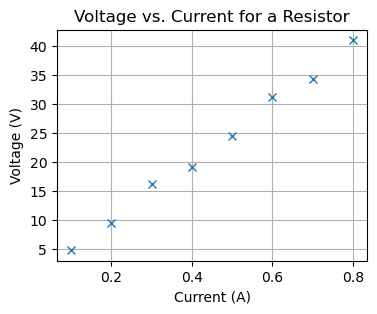

In [6]:
current = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
voltage = np.array([4.8, 9.5, 16.2, 19.1, 24.5, 31.2, 34.3, 41.0])

# Solution
plt.plot(current, voltage, marker='x', linestyle='none')
plt.title("Voltage vs. Current for a Resistor")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 12.3**</span> The relationship is linear ($y=mx+c$). Use `np.polyfit` with degree 1 to find the slope of the data from Task 12.2. This slope is the resistance $R$. Print the result.

In [7]:
# Solution
coeffs = np.polyfit(current, voltage, 1)
resistance_R = coeffs[0]
intercept = coeffs[1]

print(f"The slope (Resistance R) is: {resistance_R:.2f} Ohms")
print(f"The intercept is: {intercept:.2f} V")

The slope (Resistance R) is: 50.93 Ohms
The intercept is: -0.34 V


<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 12.4**</span> To confirm your fit is good, create a complete plot:
1. Plot the original `current` and `voltage` data as a scatter plot.
2. Use the `resistance_R` and `intercept` you found to calculate the fitted voltage values.
3. Plot the fitted voltage as a line on the same graph and add a legend.

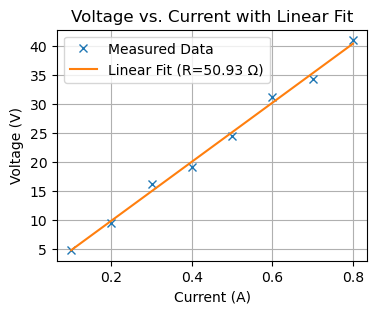

In [8]:
# Solution
voltage_fit = resistance_R * current + intercept

plt.plot(current, voltage, 'x', label='Measured Data')
plt.plot(current, voltage_fit, '-', label=f'Linear Fit (R={resistance_R:.2f} Ω)')

plt.title("Voltage vs. Current with Linear Fit")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()
plt.show()

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 12.5**</span> A new dataset is available in `data/task12_1.txt`.
1. Load the data from the file. It's a simple two-column, comma-separated file with no header.
2. Plot the data as a scatter plot to visualize it.
3. By looking at the plot, guess the order of the polynomial that would fit this data.
4. Use `np.polyfit` with your guessed order to find the coefficients.
5. Plot the fitted curve over the scatter data.

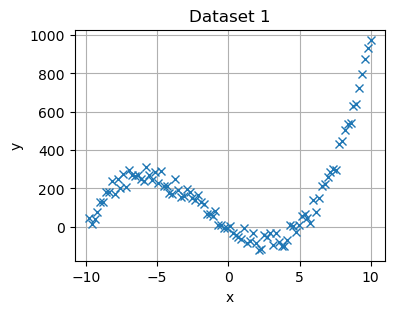

Fitted coefficients (3rd order): [  0.9987724    4.94532214 -49.63442255   2.73863187]


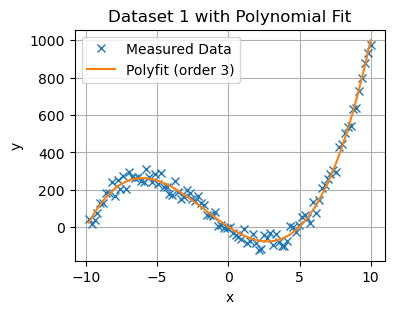

In [15]:
import pandas as pd
# 1. Load the data
data1 = pd.read_table('data/task12_1.txt', sep=' ').to_numpy() 
x1 = data1[:, 0]
y1 = data1[:, 1]

# Your solution here

# 2. Plot the data
plt.plot(x1, y1, 'x', label='Measured Data')
plt.title("Dataset 1")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

# 3. Guess the order: The curve has two turning points, suggesting a 3rd order polynomial.
poly_order = 3

# 4. Use polyfit
coeffs1 = np.polyfit(x1, y1, poly_order)
print(f"Fitted coefficients (3rd order): {coeffs1}")

# 5. Plot the fit
y1_fit = np.poly1d(coeffs1)(x1) # np.poly1d is a convenient way to create a function from coeffs
plt.plot(x1, y1, 'x', label='Measured Data')
plt.plot(x1, y1_fit, '-', label=f'Polyfit (order {poly_order})')
plt.title("Dataset 1 with Polynomial Fit")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 12.6**</span> Another dataset is in `data/task12_2.txt`.
1. Load the data.
2. Plot the data and guess the type of function (e.g., linear, quadratic, exponential, etc.).
3. Write a Python function that models your guess. For an exponential decay with a vertical offset, this would be $f(x, A, k) = A e^{-kx}$.
4. Use `scipy.optimize.curve_fit` with your model function to find the best-fit parameters.
5. Plot the fitted curve over the original data.

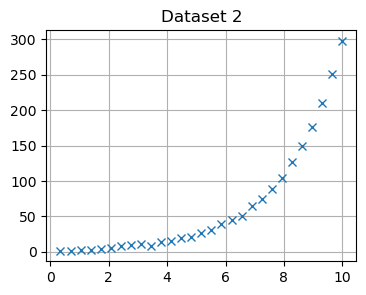

Fitted parameters [A, k, c]: [ 1.9702228  -0.50186388]


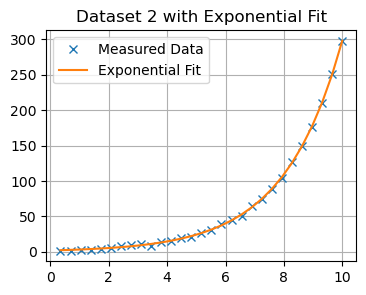

In [27]:
from scipy.optimize import curve_fit
# Solution
# 1. Load data
data2 = pd.read_table('data/task12_2.txt', sep=' ').to_numpy() 
x2 = data2[:, 0]
y2 = data2[:, 1]

# 2. Plot and guess: The data looks like an exponential decay.
plt.plot(x2, y2, 'x')
plt.title("Dataset 2")
plt.show()

# 3. Write the model function
def exp_model(x, A, k):
    return A * np.exp(-k * x)

# 4. Use curve_fit
popt2, pcov2 = curve_fit(exp_model, x2, y2)
print(f"Fitted parameters [A, k, c]: {popt2}")

# 5. Plot the fit
y2_fit = exp_model(x2, *popt2) # The '*' unpacks the popt array into A, k, c
plt.plot(x2, y2, 'x', label='Measured Data')
plt.plot(x2, y2_fit, '-', label='Exponential Fit')
plt.title("Dataset 2 with Exponential Fit")
plt.legend()
plt.grid(True)
plt.show()

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 12.7**</span> The activity of a radioactive sample is measured over time. The decay follows the law $A(t) = A_0 e^{-\lambda t}$.

Define a function for this exponential decay and use `curve_fit` to find $A_0$ and $\lambda$ from the data provided. Plot the data and the fitted curve.

<span style="font-size:12px; color:gray;">
Credits to Gemini for this task.
</span>

In [ ]:
time = np.array([0, 10, 20, 30, 40, 50, 60])
activity = np.array([100.5, 61.1, 35.6, 22.5, 14.2, 8.5, 4.9])

# Solution
def decay_model(t, A0, lam):
    return A0 * np.exp(-lam * t)

popt_decay, pcov_decay = curve_fit(decay_model, time, activity, p0=[100, 0.05])

A0_fit = popt_decay[0]
lambda_fit = popt_decay[1]

print(f"Initial Activity A0 = {A0_fit:.2f}")
print(f"Decay Constant λ = {lambda_fit:.4f}")

time_fit = np.linspace(0, 60, 100)
activity_fit = decay_model(time_fit, A0_fit, lambda_fit)

plt.plot(time, activity, 'o', label='Measured Activity')
plt.plot(time_fit, activity_fit, '-', label='Exponential Fit')
plt.xlabel("Time (s)")
plt.ylabel("Activity (Bq)")
plt.title("Radioactive Decay")
plt.legend()
plt.grid(True)
plt.show()

### Finding the Uncertainty of Fitted Parameters

In experimental physics, a result is meaningless without its uncertainty. The `curve_fit` function provides the **covariance matrix (`pcov`)** for exactly this purpose. 

The diagonal elements of this matrix are the *variances* of the fitted parameters. To get the **standard error** (the uncertainty), you just need to take the square root of these diagonal elements.

<span style="font-size:12px; color:gray;">
Credits to Gemini for this section.
</span>

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task + Solution 12.9**</span> Go back to the radioactive decay fit from **Task 12.7**. You already have the `popt_decay` and `pcov_decay` from that fit.
1. Extract the diagonal elements from `pcov_decay`.
2. Take the square root to get the standard errors for $A_0$ and $\lambda$.
3. Print the final results in the standard scientific format: `value ± uncertainty`.

In [28]:
# Solution
variances_decay = np.diag(pcov_decay)
std_errors_decay = np.sqrt(variances_decay)

A0_error = std_errors_decay[0]
lambda_error = std_errors_decay[1]

print("--- Radioactive Decay Fit Results with Uncertainty ---")
print(f"Initial Activity A0 = {A0_fit:.2f} ± {A0_error:.2f} Bq")
print(f"Decay Constant   λ = {lambda_fit:.4f} ± {lambda_error:.4f} 1/s")

--- Radioactive Decay Fit Results with Uncertainty ---
Initial Activity A0 = 100.43 ± 0.62 Bq
Decay Constant   λ = 0.0502 ± 0.0006 1/s
